In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
PROJECT_ROOT = Path(r"C:\FinPulse")

DATA_PATH = PROJECT_ROOT / "data" / "process" / "new one.csv"

CHART_PATH = PROJECT_ROOT / "python" / "charts"

CHART_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Project Root:", PROJECT_ROOT)
print("Dataset Path:", DATA_PATH)
print("Chart Path:", CHART_PATH)

Project Root: C:\FinPulse
Dataset Path: C:\FinPulse\data\process\new one.csv
Chart Path: C:\FinPulse\python\charts


In [3]:
if DATA_PATH.exists():
    print("Dataset found successfully.")
else:
    print("Dataset not found.")

Dataset found successfully.


In [4]:
df = pd.read_csv(DATA_PATH)

In [5]:
df.head()

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT
0,4.090006e+11,2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,0,1000000,1000000.0
1,4.090006e+11,2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,0,1000000,2000000.0
2,4.090006e+11,2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,0,500000,2500000.0
3,4.090006e+11,2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,0,3000000,5500000.0
4,4.090006e+11,2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,0,500000,6000000.0


In [6]:
df.head()

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT
0,4.090006e+11,2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,0,1000000,1000000.0
1,4.090006e+11,2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,0,1000000,2000000.0
2,4.090006e+11,2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,0,500000,2500000.0
3,4.090006e+11,2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,0,3000000,5500000.0
4,4.090006e+11,2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,0,500000,6000000.0


In [7]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 116202
Number of Columns: 8


In [8]:
df.columns.tolist()

['Account No',
 'DATE',
 'TRANSACTION DETAILS',
 'CHQ.NO.',
 'VALUE DATE',
 'WITHDRAWAL AMT',
 'DEPOSIT AMT',
 'BALANCE AMT']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116202 entries, 0 to 116201
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Account No           116201 non-null  float64
 1   DATE                 116201 non-null  object 
 2   TRANSACTION DETAILS  113702 non-null  object 
 3   CHQ.NO.              905 non-null     float64
 4   VALUE DATE           116201 non-null  object 
 5   WITHDRAWAL AMT       116202 non-null  int64  
 6   DEPOSIT AMT          116202 non-null  int64  
 7   BALANCE AMT          116201 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 7.1+ MB


In [10]:
df.describe(include="all")

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT
count,1.162010e+05,116201,113702,905.000000,116201,1.162020e+05,1.162020e+05,1.162010e+05
unique,NaN,1294,43213,NaN,1294,NaN,NaN,NaN
top,NaN,2017-07-27,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-27,NaN,NaN,NaN
freq,NaN,567,8839,NaN,567,NaN,NaN,NaN
mean,2.002261e+11,NaN,NaN,791614.503867,NaN,2.068739e+06,2.052376e+06,-1.404852e+09
std,2.044558e+11,NaN,NaN,151205.932910,NaN,7.696851e+06,6.652138e+06,5.348202e+08
min,1.196428e+06,NaN,NaN,1.000000,NaN,0.000000e+00,0.000000e+00,-2.045201e+09
25%,1.196428e+06,NaN,NaN,704231.000000,NaN,0.000000e+00,0.000000e+00,-1.690383e+09
50%,1.196711e+06,NaN,NaN,873812.000000,NaN,0.000000e+00,5.000000e+03,-1.661395e+09
75%,4.090004e+11,NaN,NaN,874167.000000,NaN,2.682500e+04,5.000000e+05,-1.236888e+09


In [11]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_summary.sort_values(
    "Missing Count",
    ascending=False
)

,Missing Count,Missing Percentage
CHQ.NO.,115297,99.221184
TRANSACTION DETAILS,2500,2.151426
Account No,1,0.000861
DATE,1,0.000861
VALUE DATE,1,0.000861
BALANCE AMT,1,0.000861
WITHDRAWAL AMT,0,0.000000
DEPOSIT AMT,0,0.000000


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 49


In [13]:
df = df.drop_duplicates().reset_index(drop=True)

In [14]:
print("Rows after removing duplicates:", len(df))
print("Remaining duplicates:", df.duplicated().sum())

Rows after removing duplicates: 116153
Remaining duplicates: 0


In [15]:
df["DATE"] = pd.to_datetime(
    df["DATE"],
    errors="coerce"
)

df["VALUE DATE"] = pd.to_datetime(
    df["VALUE DATE"],
    errors="coerce"
)

In [16]:
amount_columns = [
    "WITHDRAWAL AMT",
    "DEPOSIT AMT",
    "BALANCE AMT"
]

In [17]:
for column in amount_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

In [18]:
df[amount_columns].dtypes

WITHDRAWAL AMT      int64
DEPOSIT AMT         int64
BALANCE AMT       float64
dtype: object

In [19]:
df["WITHDRAWAL AMT"] = (
    df["WITHDRAWAL AMT"].fillna(0)
)

df["DEPOSIT AMT"] = (
    df["DEPOSIT AMT"].fillna(0)
)

In [20]:
df.isnull().sum()

Account No                  1
DATE                        1
TRANSACTION DETAILS      2500
CHQ.NO.                115248
VALUE DATE                  1
WITHDRAWAL AMT              0
DEPOSIT AMT                 0
BALANCE AMT                 1
dtype: int64

In [21]:
print("First Transaction Date:")
print(df["DATE"].min())

print("\nLast Transaction Date:")
print(df["DATE"].max())

First Transaction Date:
2015-01-01 00:00:00

Last Transaction Date:
2019-03-05 00:00:00


In [22]:
unique_accounts = df["Account No"].nunique()

print("Unique Accounts:", unique_accounts)

Unique Accounts: 10


In [23]:
df["TRANSACTION TYPE"] = np.select(
    [
        df["DEPOSIT AMT"] > 0,
        df["WITHDRAWAL AMT"] > 0
    ],
    [
        "Deposit",
        "Withdrawal"
    ],
    default="Other"
)

In [24]:
df["TRANSACTION TYPE"].value_counts()

TRANSACTION TYPE
Deposit       62467
Withdrawal    41572
Other         12114
Name: count, dtype: int64

In [25]:
df["NET AMOUNT"] = (
    df["DEPOSIT AMT"]
    - df["WITHDRAWAL AMT"]
)

In [26]:
df[
    [
        "DEPOSIT AMT",
        "WITHDRAWAL AMT",
        "NET AMOUNT"
    ]
].tail()

,DEPOSIT AMT,WITHDRAWAL AMT,NET AMOUNT
116148,300000,117934,182066
116149,300000,0,300000
116150,0,0,0
116151,0,109869,-109869
116152,0,5000,-5000


In [27]:
df["YEAR"] = df["DATE"].dt.year

df["MONTH"] = df["DATE"].dt.month

df["MONTH NAME"] = df["DATE"].dt.month_name()

df["DAY"] = df["DATE"].dt.day

df["DAY NAME"] = df["DATE"].dt.day_name()

df["WEEKDAY"] = df["DATE"].dt.dayofweek

In [28]:
df.head()

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,TRANSACTION TYPE,NET AMOUNT,YEAR,MONTH,MONTH NAME,DAY,DAY NAME,WEEKDAY
0,4.090006e+11,2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,0,1000000,1000000.0,Deposit,1000000,2017.0,6.0,June,29.0,Thursday,3.0
1,4.090006e+11,2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,0,1000000,2000000.0,Deposit,1000000,2017.0,7.0,July,5.0,Wednesday,2.0
2,4.090006e+11,2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,0,500000,2500000.0,Deposit,500000,2017.0,7.0,July,18.0,Tuesday,1.0
3,4.090006e+11,2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,0,3000000,5500000.0,Deposit,3000000,2017.0,8.0,August,1.0,Tuesday,1.0
4,4.090006e+11,2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,0,500000,6000000.0,Deposit,500000,2017.0,8.0,August,16.0,Wednesday,2.0


In [29]:
total_transactions = len(df)

total_deposits = df["DEPOSIT AMT"].sum()

total_withdrawals = df["WITHDRAWAL AMT"].sum()

net_cash_flow = df["NET AMOUNT"].sum()

average_transaction = (
    df["NET AMOUNT"].abs().mean()
)

In [30]:
balance_df = df.sort_values(
    ["DATE", "VALUE DATE"]
).copy()

In [31]:
starting_balance = (
    balance_df["BALANCE AMT"].iloc[0]
)

ending_balance = (
    balance_df["BALANCE AMT"].iloc[-1]
)

highest_balance = (
    balance_df["BALANCE AMT"].max()
)

lowest_balance = (
    balance_df["BALANCE AMT"].min()
)

In [32]:
print("========== FINPULSE KPIs ==========")

print(
    f"Total Transactions : {total_transactions:,}"
)

print(
    f"Total Deposits     : {total_deposits:,.2f}"
)

print(
    f"Total Withdrawals  : {total_withdrawals:,.2f}"
)

print(
    f"Net Cash Flow      : {net_cash_flow:,.2f}"
)

print(
    f"Average Transaction: {average_transaction:,.2f}"
)

print(
    f"Starting Balance   : {starting_balance:,.2f}"
)

print(
    f"Ending Balance     : {ending_balance:,.2f}"
)

print(
    f"Highest Balance    : {highest_balance:,.2f}"
)

print(
    f"Lowest Balance     : {lowest_balance:,.2f}"
)

========== FINPULSE KPIs ==========
Total Transactions : 116,153
Total Deposits     : 238,430,215,306.00
Total Withdrawals  : 240,284,632,304.00
Net Cash Flow      : -1,854,416,998.00
Average Transaction: 3,853,989.88
Starting Balance   : -539,958,122.00
Ending Balance     : nan
Highest Balance    : 8,500,000.00
Lowest Balance     : -2,045,201,142.00


In [33]:
transaction_summary = (
    df.groupby("TRANSACTION TYPE")
      .agg(
          transaction_count=(
              "TRANSACTION TYPE",
              "count"
          ),
          total_amount=(
              "NET AMOUNT",
              "sum"
          )
      )
      .reset_index()
)

In [34]:
transaction_summary

,TRANSACTION TYPE,transaction_count,total_amount
0,Deposit,62467,112400864492
1,Other,12114,0
2,Withdrawal,41572,-114255281490


In [35]:
transaction_summary["percentage"] = (
    transaction_summary["transaction_count"]
    / transaction_summary["transaction_count"].sum()
    * 100
)

In [36]:
transaction_summary

,TRANSACTION TYPE,transaction_count,total_amount,percentage
0,Deposit,62467,112400864492,53.779928
1,Other,12114,0,10.429347
2,Withdrawal,41572,-114255281490,35.790724


In [37]:
deposit_analysis = {
    "Total Deposits": df["DEPOSIT AMT"].sum(),

    "Average Deposit": df.loc[
        df["DEPOSIT AMT"] > 0,
        "DEPOSIT AMT"
    ].mean(),

    "Maximum Deposit": df["DEPOSIT AMT"].max(),

    "Minimum Deposit": df.loc[
        df["DEPOSIT AMT"] > 0,
        "DEPOSIT AMT"
    ].min()
}

In [38]:
pd.Series(deposit_analysis)

Total Deposits     2.384302e+11
Average Deposit    3.816899e+06
Maximum Deposit    5.448000e+08
Minimum Deposit    1.000000e+00
dtype: float64

In [39]:
top_deposits = (
    df.nlargest(
        10,
        "DEPOSIT AMT"
    )
    [
        [
            "DATE",
            "TRANSACTION DETAILS",
            "DEPOSIT AMT",
            "BALANCE AMT"
        ]
    ]
)

In [40]:
top_deposits

,DATE,TRANSACTION DETAILS,DEPOSIT AMT,BALANCE AMT
13592,2016-02-25,GOLD LABEL INVESTMENTS (P,544800000,-1.514640e+06
36485,2017-04-28,909000039501 Draw Down Cr,500000000,-1.536160e+09
36576,2017-05-29,Loan Payment Reversal For,448207223,-1.587987e+09
37495,2018-10-31,TRF FROM Indiaforensic SERVICES,354000000,-1.568781e+09
55851,2016-10-13,NEFT/CITIN16697927307/PAY,211959442,-1.473398e+09
31465,2015-12-14,RTGS/SBINH15348462974/Indfor,205000000,-1.512764e+09
2950,2016-05-03,TRF FROM Indiaforensic SERVICES,202100000,-3.566520e+08
32753,2016-03-18,TRF FROM Indiaforensic SERVICES,200000000,-1.352038e+09
88250,2015-10-03,TRF FROM Indiaforensic SERVICES,200000000,-1.443498e+09
88713,2015-10-21,FUND TRF FROM Indiaforensic SER,200000000,-1.474670e+09


In [41]:
withdrawal_analysis = {
    "Total Withdrawals": df["WITHDRAWAL AMT"].sum(),

    "Average Withdrawal": df.loc[
        df["WITHDRAWAL AMT"] > 0,
        "WITHDRAWAL AMT"
    ].mean(),

    "Maximum Withdrawal": df["WITHDRAWAL AMT"].max(),

    "Minimum Withdrawal": df.loc[
        df["WITHDRAWAL AMT"] > 0,
        "WITHDRAWAL AMT"
    ].min()
}

In [42]:
pd.Series(withdrawal_analysis)

Total Withdrawals     2.402846e+11
Average Withdrawal    4.490462e+06
Maximum Withdrawal    4.594475e+08
Minimum Withdrawal    1.000000e+00
dtype: float64

In [43]:
top_withdrawals = (
    df.nlargest(
        10,
        "WITHDRAWAL AMT"
    )
    [
        [
            "DATE",
            "TRANSACTION DETAILS",
            "WITHDRAWAL AMT",
            "BALANCE AMT"
        ]
    ]
)

In [44]:
top_withdrawals

,DATE,TRANSACTION DETAILS,WITHDRAWAL AMT,BALANCE AMT
37320,2018-06-26,Loan Recovery For90900005,459447546,-1.931001e+09
36574,2017-05-26,NEFT/CITIN17782836874/PAY,448207223,-2.036195e+09
13612,2016-03-11,TRF TO Indiaforensic SERVICES IN,400000000,-5.234147e+08
2927,2018-10-31,TRF TO Indiaforensic SERVICES I,354000000,-3.544408e+08
27065,2015-06-22,ACCRUAL BOOKES FEE RECOVE,267140318,-9.083787e+08
3023,2016-05-18,RUPAY POS ACQ SETTL 14051,240000000,-5.480176e+08
33597,2016-05-03,RTGS/PUNBH16124408848/Indfor,202100000,-1.558700e+09
13618,2016-03-14,RTGS/ICICH16074260960/Indfor,200000000,-5.304147e+08
13637,2016-07-15,Indiaforensic AEPS NPCI WDL SET,200000000,-5.451133e+08
29630,2015-10-03,NEFT/AXISF15276010395/Indfor,200000000,-1.499006e+09


In [45]:
monthly_analysis = (
    df.groupby(
        ["YEAR", "MONTH"]
    )
    .agg(
        transactions=("DATE", "count"),
        deposits=("DEPOSIT AMT", "sum"),
        withdrawals=("WITHDRAWAL AMT", "sum"),
        net_cash_flow=("NET AMOUNT", "sum")
    )
    .reset_index()
)

In [47]:
monthly_analysis["MONTH DATE"] = pd.to_datetime(
    monthly_analysis["YEAR"].astype(int).astype(str)
    + "-"
    + monthly_analysis["MONTH"].astype(int).astype(str)
    + "-01",
    format="%Y-%m-%d"
)

In [49]:
monthly_analysis = monthly_analysis.sort_values(
    "MONTH DATE"
)

monthly_analysis.head()

,YEAR,MONTH,transactions,deposits,withdrawals,net_cash_flow,MONTH DATE
0,2015.0,1.0,204,116246479,118226447,-1979968,2015-01-01
1,2015.0,2.0,264,126872940,125428742,1444198,2015-02-01
2,2015.0,3.0,239,108534650,112995472,-4460822,2015-03-01
3,2015.0,4.0,256,116687860,116198736,489124,2015-04-01
4,2015.0,5.0,378,161203770,160613236,590534,2015-05-01


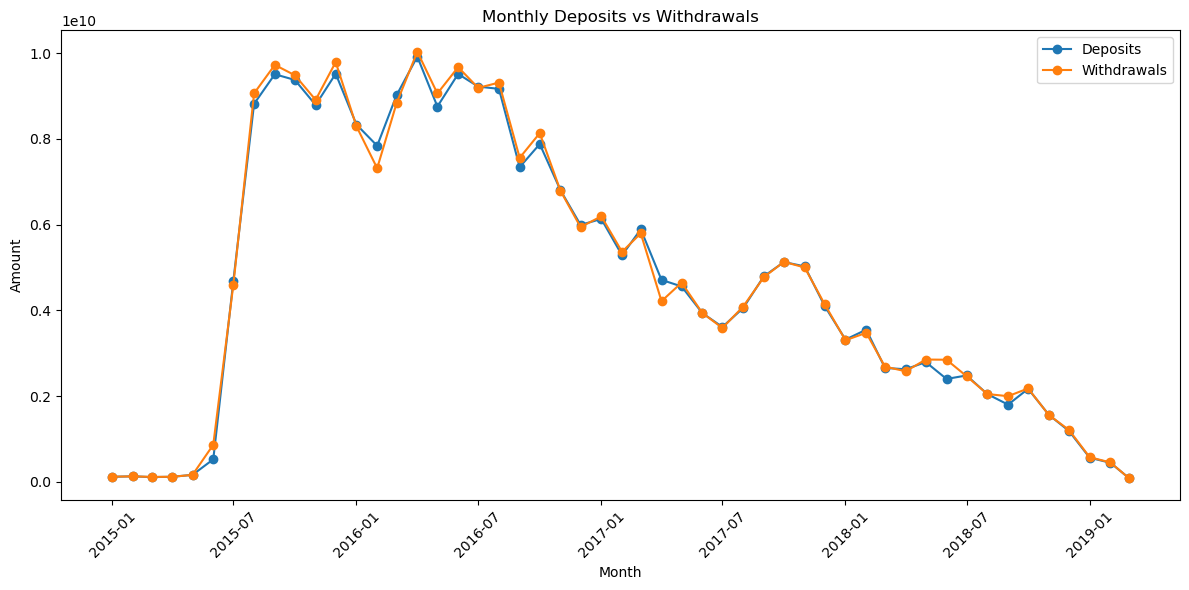

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis["MONTH DATE"],
    monthly_analysis["deposits"],
    marker="o",
    label="Deposits"
)

plt.plot(
    monthly_analysis["MONTH DATE"],
    monthly_analysis["withdrawals"],
    marker="o",
    label="Withdrawals"
)

plt.title("Monthly Deposits vs Withdrawals")

plt.xlabel("Month")

plt.ylabel("Amount")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.savefig(
    CHART_PATH / "monthly_deposits_vs_withdrawals.png",
    dpi=300,
    bbox_inches="tight"
)

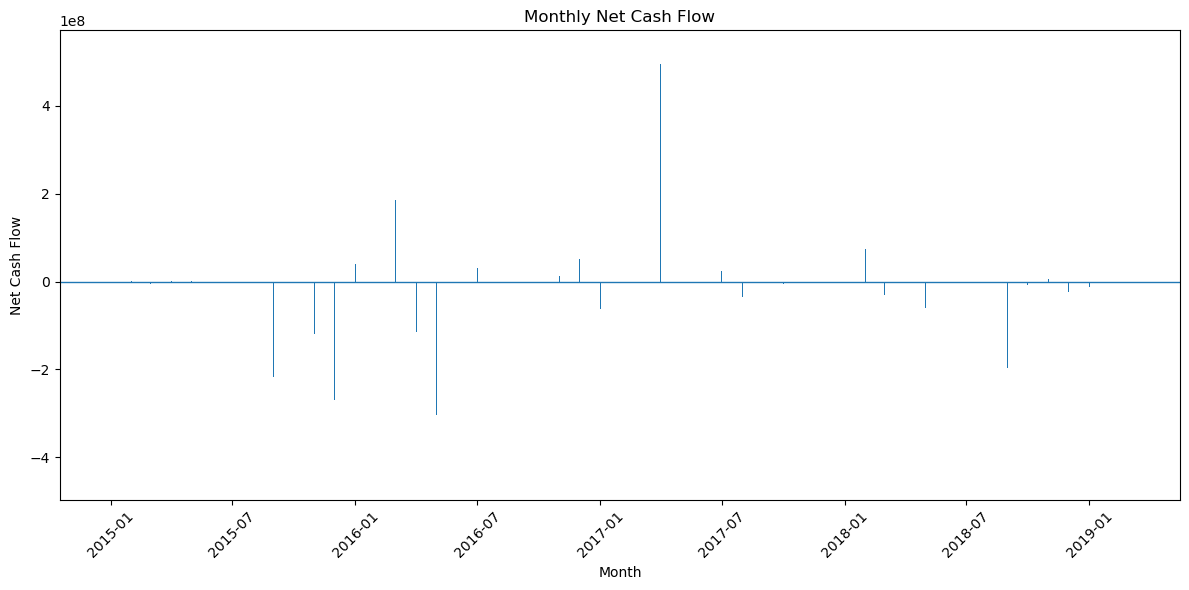

In [51]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_analysis["MONTH DATE"],
    monthly_analysis["net_cash_flow"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Monthly Net Cash Flow")

plt.xlabel("Month")

plt.ylabel("Net Cash Flow")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    CHART_PATH / "monthly_net_cashflow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
# Monthly ending balance
monthly_balance = (
    balance_df
    .set_index("DATE")
    .resample("ME")["BALANCE AMT"]
    .last()
    .reset_index()
)

monthly_balance.head()

,DATE,BALANCE AMT
0,2015-01-31,-1.584506e+09
1,2015-02-28,-1.583050e+09
2,2015-03-31,-1.587500e+09
3,2015-04-30,-1.587011e+09
4,2015-05-31,-1.586420e+09


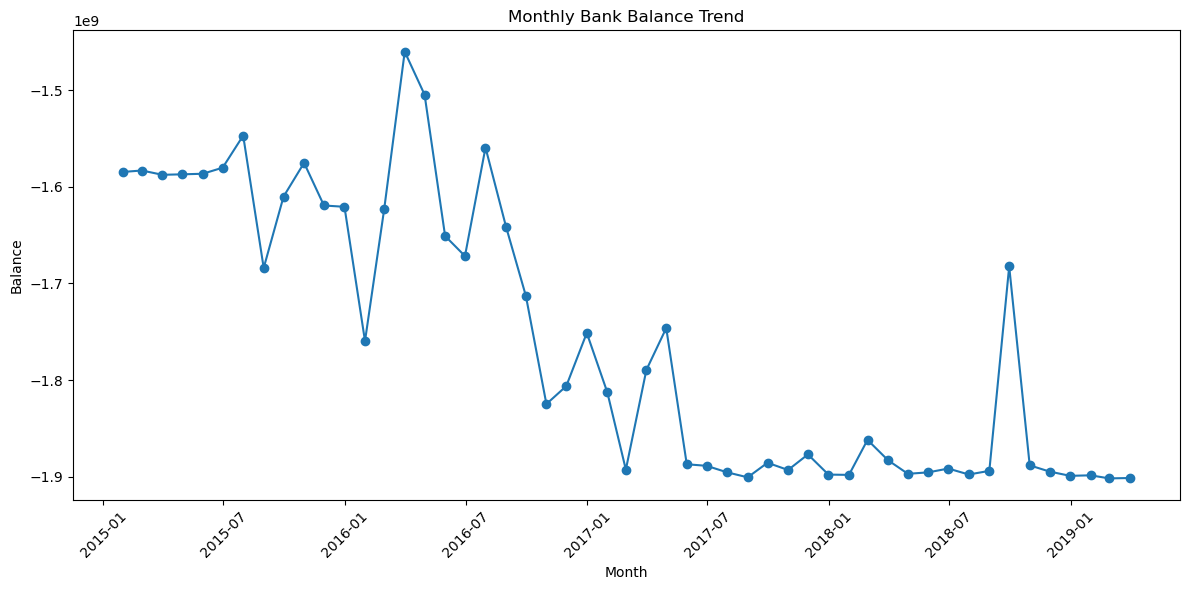

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_balance["DATE"],
    monthly_balance["BALANCE AMT"],
    marker="o"
)

plt.title("Monthly Bank Balance Trend")

plt.xlabel("Month")
plt.ylabel("Balance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    CHART_PATH / "balance_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
transaction_counts = (
    df["TRANSACTION TYPE"]
    .value_counts()
)

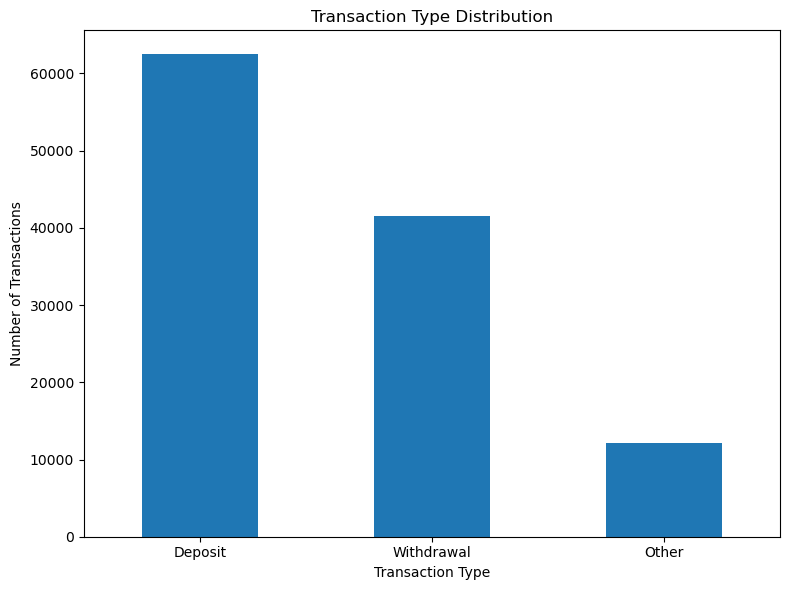

In [57]:
plt.figure(figsize=(8, 6))

transaction_counts.plot(
    kind="bar"
)

plt.title("Transaction Type Distribution")

plt.xlabel("Transaction Type")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    CHART_PATH / "transaction_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [58]:
top_transaction_details = (
    df["TRANSACTION DETAILS"]
    .value_counts()
    .head(20)
)

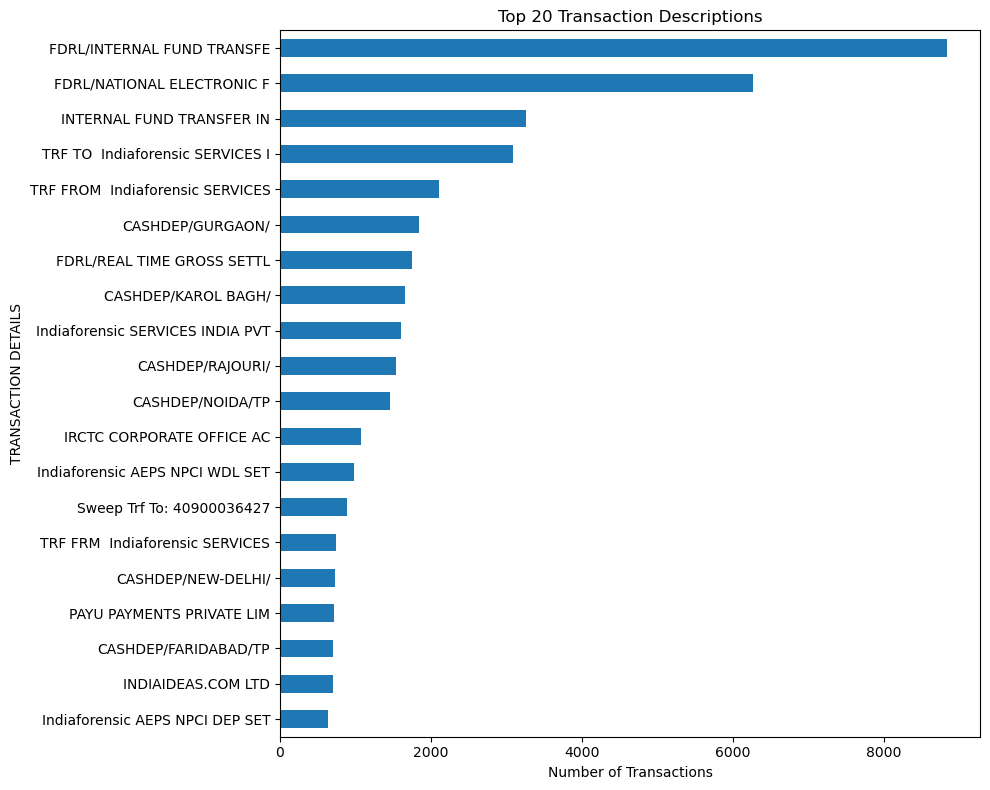

In [59]:
plt.figure(figsize=(10, 8))

top_transaction_details.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Transaction Descriptions"
)

plt.xlabel("Number of Transactions")

plt.tight_layout()

plt.savefig(
    CHART_PATH / "top_transaction_descriptions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
top_deposit_chart = (
    df.nlargest(
        10,
        "DEPOSIT AMT"
    )
    .sort_values("DEPOSIT AMT")
)

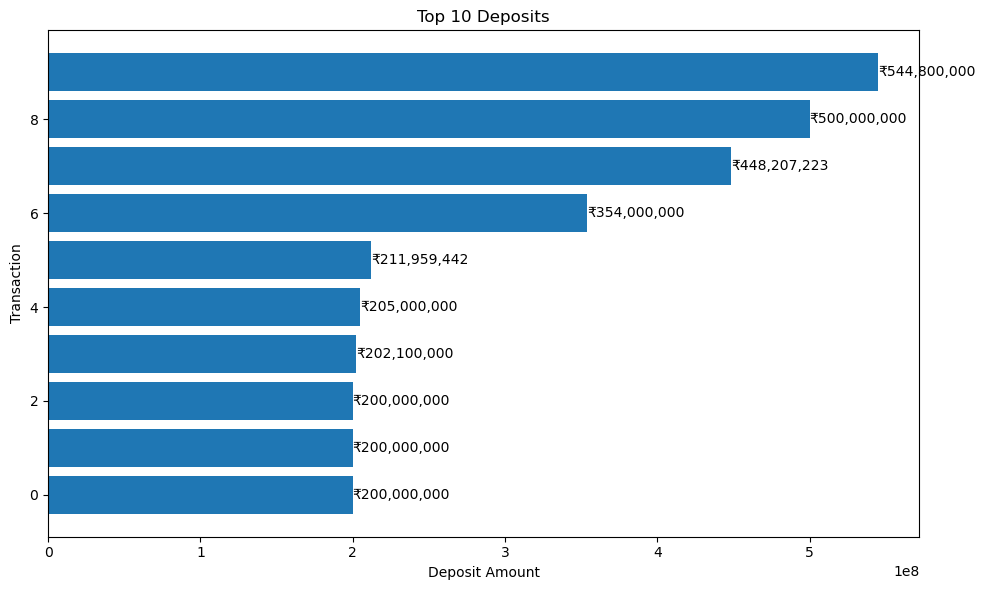

In [62]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    range(len(top_deposit_chart)),
    top_deposit_chart["DEPOSIT AMT"]
)

plt.title("Top 10 Deposits")
plt.xlabel("Deposit Amount")
plt.ylabel("Transaction")

# Add values on bars
for i, bar in enumerate(bars):
    value = top_deposit_chart["DEPOSIT AMT"].iloc[i]

    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"₹{value:,.0f}",
        va="center",
        ha="left"
    )

plt.tight_layout()

plt.savefig(
    CHART_PATH / "top_10_deposits.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
top_withdrawal_chart = (
    df.nlargest(
        10,
        "WITHDRAWAL AMT"
    )
    .sort_values("WITHDRAWAL AMT")
)

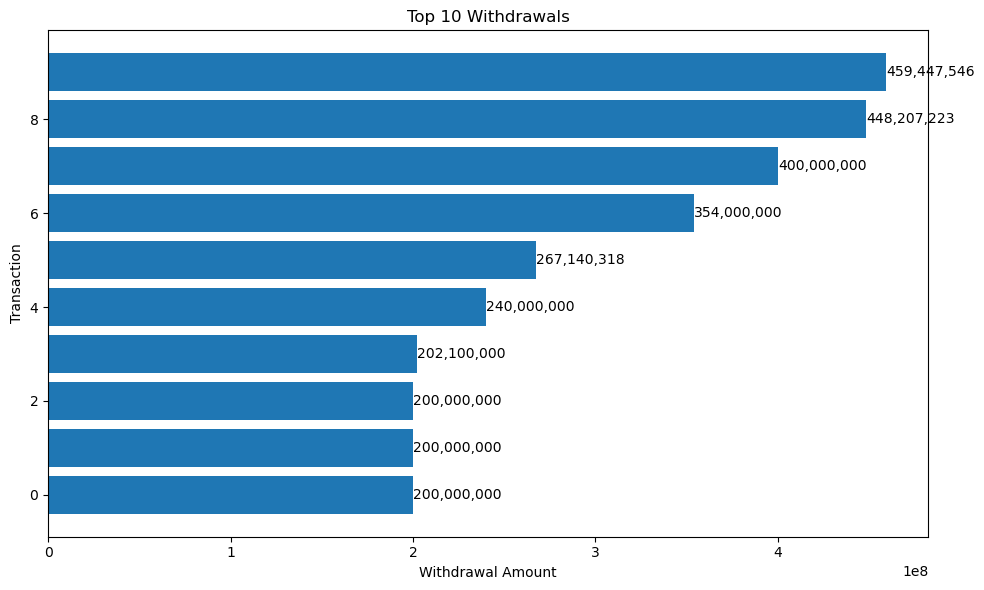

In [64]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    range(len(top_withdrawal_chart)),
    top_withdrawal_chart["WITHDRAWAL AMT"]
)

plt.title("Top 10 Withdrawals")

plt.xlabel("Withdrawal Amount")
plt.ylabel("Transaction")

# Withdrawal values show karna
for i, bar in enumerate(bars):
    value = top_withdrawal_chart["WITHDRAWAL AMT"].iloc[i]

    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left"
    )

plt.tight_layout()

plt.savefig(
    CHART_PATH / "top_10_withdrawals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
transaction_values = (
    df["NET AMOUNT"].abs()
)

In [66]:
threshold = transaction_values.quantile(0.99)

print(
    f"High-value transaction threshold: {threshold:,.2f}"
)

High-value transaction threshold: 42,050,948.08


In [67]:
high_value_transactions = (
    df[
        transaction_values >= threshold
    ]
    .sort_values(
        "NET AMOUNT",
        key=lambda x: x.abs(),
        ascending=False
    )
)

In [68]:
high_value_transactions[
    [
        "DATE",
        "TRANSACTION DETAILS",
        "DEPOSIT AMT",
        "WITHDRAWAL AMT",
        "NET AMOUNT",
        "BALANCE AMT"
    ]
].head(20)

,DATE,TRANSACTION DETAILS,DEPOSIT AMT,WITHDRAWAL AMT,NET AMOUNT,BALANCE AMT
13592,2016-02-25,GOLD LABEL INVESTMENTS (P,544800000,0,544800000,-1.514640e+06
36485,2017-04-28,909000039501 Draw Down Cr,500000000,1150000,498850000,-1.536160e+09
37320,2018-06-26,Loan Recovery For90900005,0,459447546,-459447546,-1.931001e+09
36576,2017-05-29,Loan Payment Reversal For,448207223,0,448207223,-1.587987e+09
36574,2017-05-26,NEFT/CITIN17782836874/PAY,5895,448207223,-448201328,-2.036195e+09
13612,2016-03-11,TRF TO Indiaforensic SERVICES IN,0,400000000,-400000000,-5.234147e+08
2927,2018-10-31,TRF TO Indiaforensic SERVICES I,0,354000000,-354000000,-3.544408e+08
37495,2018-10-31,TRF FROM Indiaforensic SERVICES,354000000,0,354000000,-1.568781e+09
27065,2015-06-22,ACCRUAL BOOKES FEE RECOVE,0,267140318,-267140318,-9.083787e+08
3023,2016-05-18,RUPAY POS ACQ SETTL 14051,44,240000000,-239999956,-5.480176e+08


In [69]:
deposit_q1 = df["DEPOSIT AMT"].quantile(0.25)

deposit_q3 = df["DEPOSIT AMT"].quantile(0.75)

deposit_iqr = (
    deposit_q3 - deposit_q1
)

deposit_upper_limit = (
    deposit_q3
    + 1.5 * deposit_iqr
)

In [70]:
deposit_outliers = df[
    df["DEPOSIT AMT"] > deposit_upper_limit
]

In [71]:
print(
    "Deposit Outliers:",
    len(deposit_outliers)
)

Deposit Outliers: 21912


In [72]:
withdrawal_q1 = (
    df["WITHDRAWAL AMT"].quantile(0.25)
)

withdrawal_q3 = (
    df["WITHDRAWAL AMT"].quantile(0.75)
)

withdrawal_iqr = (
    withdrawal_q3 - withdrawal_q1
)

withdrawal_upper_limit = (
    withdrawal_q3
    + 1.5 * withdrawal_iqr
)

In [73]:
withdrawal_outliers = df[
    df["WITHDRAWAL AMT"]
    > withdrawal_upper_limit
]

In [74]:
print(
    "Withdrawal Outliers:",
    len(withdrawal_outliers)
)

Withdrawal Outliers: 25672


In [75]:
numeric_columns = [
    "WITHDRAWAL AMT",
    "DEPOSIT AMT",
    "BALANCE AMT",
    "NET AMOUNT"
]

In [76]:
correlation = (
    df[numeric_columns]
    .corr()
)

correlation

,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,NET AMOUNT
WITHDRAWAL AMT,1.000000,-0.038101,-0.075131,-0.767167
DEPOSIT AMT,-0.038101,1.000000,-0.070669,0.670211
BALANCE AMT,-0.075131,-0.070669,1.000000,0.010437
NET AMOUNT,-0.767167,0.670211,0.010437,1.000000


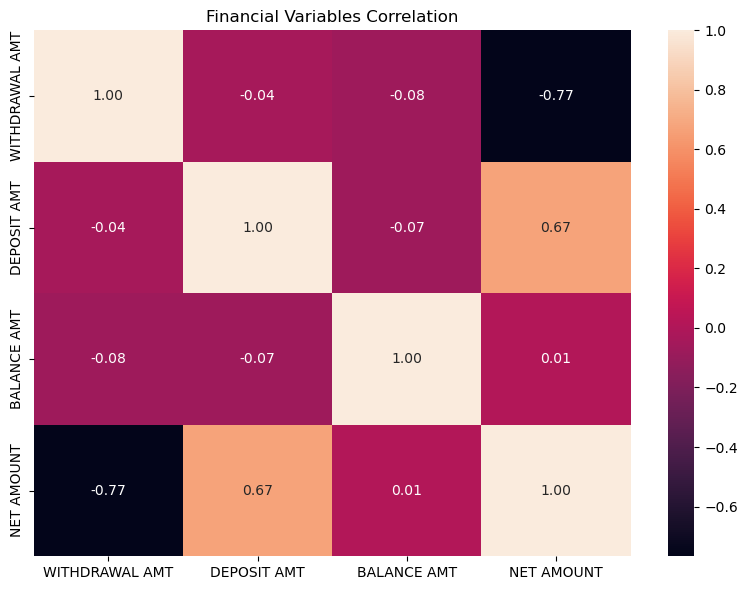

In [77]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Financial Variables Correlation"
)

plt.tight_layout()

plt.savefig(
    CHART_PATH / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
monthly_analysis.to_csv(
    PROJECT_ROOT
    / "python"
    / "charts"
    / "monthly_analysis.csv",
    index=False)

In [81]:

print("        FINPULSE SUMMARY"  )

print(
    f"Total Transactions : {len(df):,}"
)

print(
    f"Total Deposits     : {df['DEPOSIT AMT'].sum():,.2f}"
)

print(
    f"Total Withdrawals  : {df['WITHDRAWAL AMT'].sum():,.2f}"
)

print(
    f"Net Cash Flow      : {df['NET AMOUNT'].sum():,.2f}"
)

print(
    f"Starting Balance   : {balance_df['BALANCE AMT'].iloc[0]:,.2f}"
)

print(
    f"Ending Balance     : {balance_df['BALANCE AMT'].iloc[-1]:,.2f}"
)

print(
    f"Highest Deposit    : {df['DEPOSIT AMT'].max():,.2f}"
)

print(
    f"Highest Withdrawal : {df['WITHDRAWAL AMT'].max():,.2f}"
)


        FINPULSE SUMMARY
Total Transactions : 116,153
Total Deposits     : 238,430,215,306.00
Total Withdrawals  : 240,284,632,304.00
Net Cash Flow      : -1,854,416,998.00
Starting Balance   : -539,958,122.00
Ending Balance     : nan
Highest Deposit    : 544,800,000.00
Highest Withdrawal : 459,447,546.00


In [82]:
df.head()

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,TRANSACTION TYPE,NET AMOUNT,YEAR,MONTH,MONTH NAME,DAY,DAY NAME,WEEKDAY
0,4.090006e+11,2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,0,1000000,1000000.0,Deposit,1000000,2017.0,6.0,June,29.0,Thursday,3.0
1,4.090006e+11,2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,0,1000000,2000000.0,Deposit,1000000,2017.0,7.0,July,5.0,Wednesday,2.0
2,4.090006e+11,2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,0,500000,2500000.0,Deposit,500000,2017.0,7.0,July,18.0,Tuesday,1.0
3,4.090006e+11,2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,0,3000000,5500000.0,Deposit,3000000,2017.0,8.0,August,1.0,Tuesday,1.0
4,4.090006e+11,2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,0,500000,6000000.0,Deposit,500000,2017.0,8.0,August,16.0,Wednesday,2.0


In [83]:

POWERBI_PATH = PROJECT_ROOT / "data" / "process" / "FinPulse_PowerBI.csv"
df.to_csv(POWERBI_PATH,index=False,
    encoding="utf-8-sig")
print("saved successfully")

saved successfully
